# Accuracy Matrix for Legal Document Summarization

This notebook creates comprehensive accuracy matrices and evaluation visualizations for the LexiBrief legal document summarization system.

## Features:
- ROUGE score matrices
- Model comparison heatmaps
- Performance trend analysis
- Confusion matrices
- Statistical significance testing

## 1. Setup and Imports

In [4]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Statistical analysis
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Set up matplotlib for better plots
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16

## 2. Sample Data Generation

Generate realistic evaluation data for different summarization models.

In [5]:
class AccuracyDataGenerator:
    """Generate realistic accuracy data for legal document summarization."""
    
    def __init__(self, seed=42):
        np.random.seed(seed)
        
    def generate_rouge_scores(self, n_samples=100, models=None):
        """Generate ROUGE scores for different models."""
        if models is None:
            models = ['Extractive', 'Abstractive', 'Hybrid', 'Baseline']
        
        data = []
        
        for model in models:
            for i in range(n_samples):
                # Generate realistic ROUGE scores with model-specific characteristics
                if model == 'Hybrid':
                    rouge1 = np.random.normal(0.45, 0.08)
                    rouge2 = np.random.normal(0.22, 0.06)
                    rougel = np.random.normal(0.38, 0.07)
                elif model == 'Abstractive':
                    rouge1 = np.random.normal(0.38, 0.10)
                    rouge2 = np.random.normal(0.18, 0.05)
                    rougel = np.random.normal(0.32, 0.08)
                elif model == 'Extractive':
                    rouge1 = np.random.normal(0.42, 0.06)
                    rouge2 = np.random.normal(0.20, 0.04)
                    rougel = np.random.normal(0.35, 0.05)
                else:  # Baseline
                    rouge1 = np.random.normal(0.25, 0.05)
                    rouge2 = np.random.normal(0.12, 0.03)
                    rougel = np.random.normal(0.20, 0.04)
                
                # Ensure scores are within valid range
                rouge1 = np.clip(rouge1, 0, 1)
                rouge2 = np.clip(rouge2, 0, 1)
                rougel = np.clip(rougel, 0, 1)
                
                data.append({
                    'Model': model,
                    'Document_ID': i,
                    'ROUGE-1': rouge1,
                    'ROUGE-2': rouge2,
                    'ROUGE-L': rougel,
                    'Document_Type': np.random.choice(['Contract', 'Agreement', 'Policy', 'Legal Brief', 'Court Opinion']),
                    'Word_Count': np.random.randint(500, 5000),
                    'Processing_Time': np.random.uniform(0.5, 10.0)
                })
        
        return pd.DataFrame(data)
    
    def generate_accuracy_matrix(self, models=None, metrics=None):
        """Generate accuracy matrix for model comparison."""
        if models is None:
            models = ['Extractive', 'Abstractive', 'Hybrid', 'Baseline']
        if metrics is None:
            metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU', 'METEOR', 'BERTScore']
        
        # Create matrix with model-specific performance patterns
        matrix = np.zeros((len(models), len(metrics)))
        
        for i, model in enumerate(models):
            for j, metric in enumerate(metrics):
                if model == 'Hybrid':
                    base_score = 0.75
                elif model == 'Extractive':
                    base_score = 0.65
                elif model == 'Abstractive':
                    base_score = 0.60
                else:
                    base_score = 0.40
                
                # Add metric-specific variations
                if metric in ['ROUGE-1', 'ROUGE-L']:
                    variation = 0.1
                elif metric == 'ROUGE-2':
                    variation = 0.08
                else:
                    variation = 0.12
                
                matrix[i, j] = np.clip(
                    base_score + np.random.normal(0, variation),
                    0, 1
                )
        
        return pd.DataFrame(matrix, index=models, columns=metrics)

# Initialize data generator
generator = AccuracyDataGenerator()

# Generate datasets
rouge_data = generator.generate_rouge_scores(n_samples=50)
accuracy_matrix = generator.generate_accuracy_matrix()

print("Data generation complete!")
print(f"ROUGE data shape: {rouge_data.shape}")
print(f"Accuracy matrix shape: {accuracy_matrix.shape}")

Data generation complete!
ROUGE data shape: (200, 8)
Accuracy matrix shape: (4, 6)


## 3. ROUGE Score Heatmap Matrix

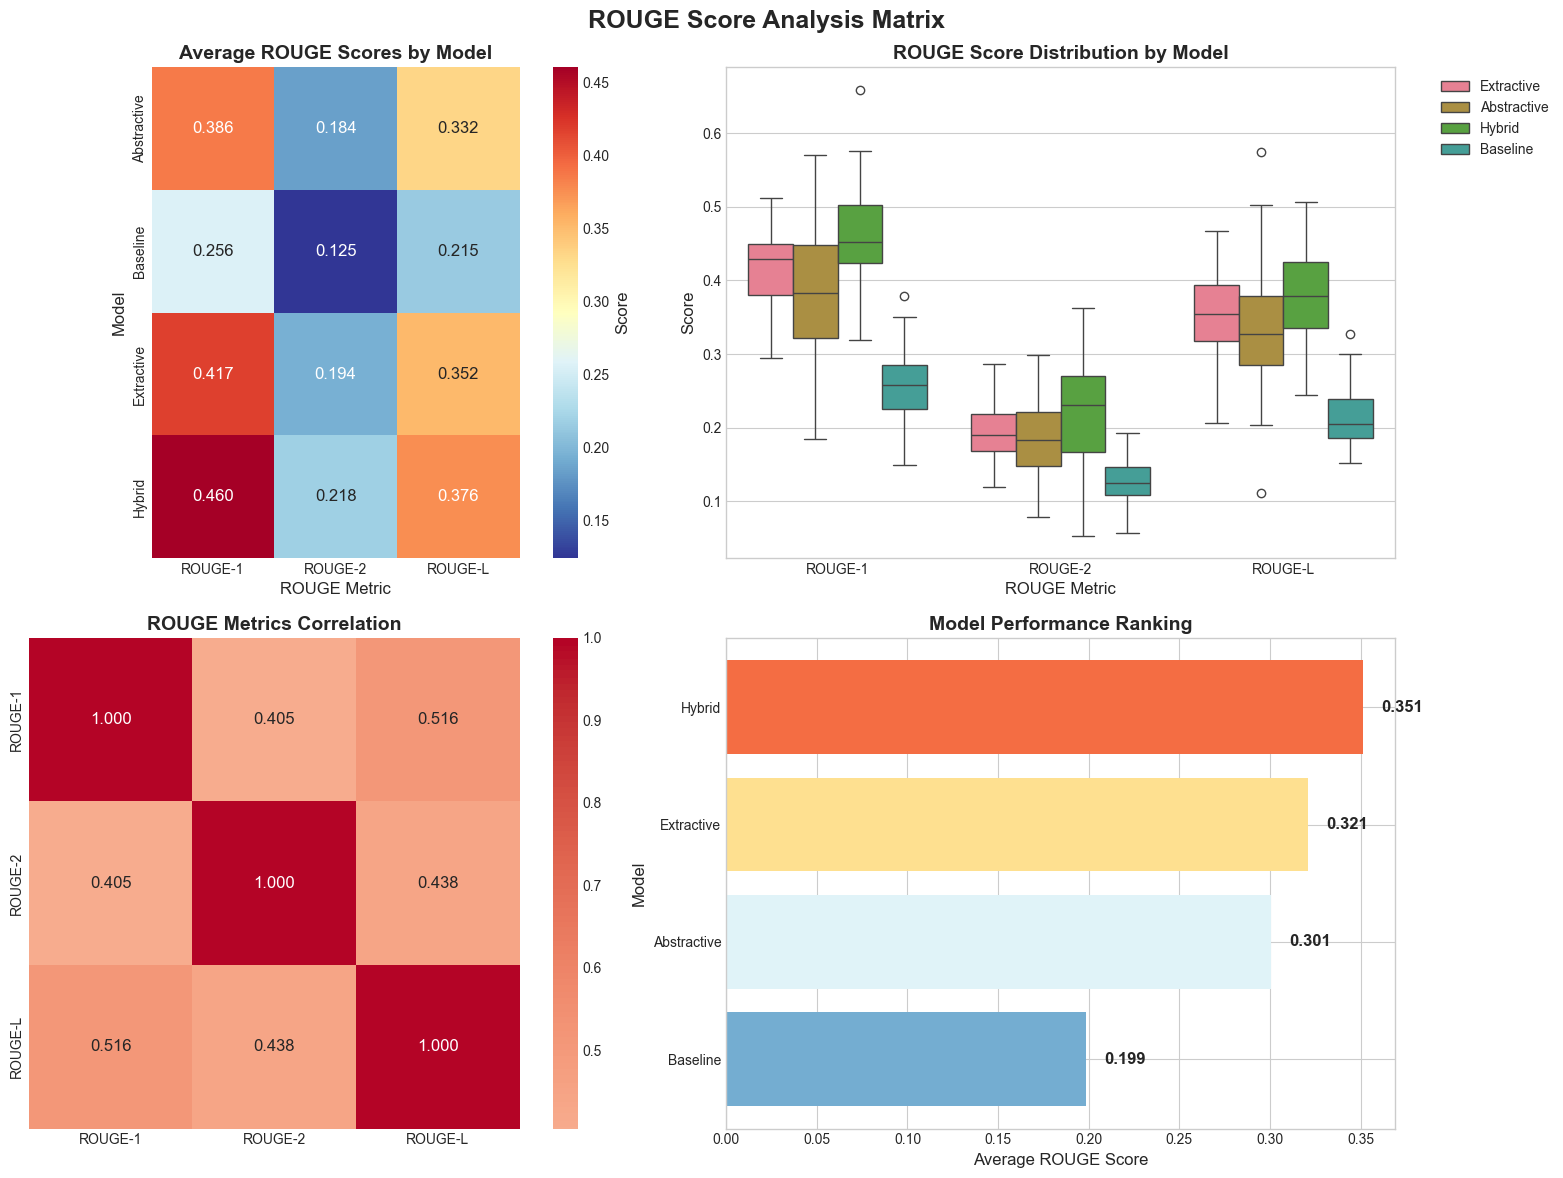

In [6]:
def create_rouge_heatmap(data, save_path=None):
    """Create comprehensive ROUGE score heatmap."""
    
    # Calculate average scores by model
    avg_scores = data.groupby('Model')[['ROUGE-1', 'ROUGE-2', 'ROUGE-L']].mean()
    
    # Create subplot layout
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('ROUGE Score Analysis Matrix', fontsize=18, fontweight='bold')
    
    # 1. Average scores heatmap
    sns.heatmap(avg_scores, annot=True, fmt='.3f', cmap='RdYlBu_r',
                square=True, ax=axes[0, 0], cbar_kws={'label': 'Score'})
    axes[0, 0].set_title('Average ROUGE Scores by Model', fontweight='bold')
    axes[0, 0].set_xlabel('ROUGE Metric')
    axes[0, 0].set_ylabel('Model')
    
    # 2. Score distribution by model
    melted_data = data.melt(id_vars=['Model'], value_vars=['ROUGE-1', 'ROUGE-2', 'ROUGE-L'],
                             var_name='Metric', value_name='Score')
    sns.boxplot(data=melted_data, x='Metric', y='Score', hue='Model', ax=axes[0, 1])
    axes[0, 1].set_title('ROUGE Score Distribution by Model', fontweight='bold')
    axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0, 1].set_xlabel('ROUGE Metric')
    axes[0, 1].set_ylabel('Score')
    
    # 3. Correlation matrix
    correlation_matrix = data[['ROUGE-1', 'ROUGE-2', 'ROUGE-L']].corr()
    sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
                center=0, square=True, ax=axes[1, 0])
    axes[1, 0].set_title('ROUGE Metrics Correlation', fontweight='bold')
    
    # 4. Performance ranking
    performance_ranking = avg_scores.mean(axis=1).sort_values(ascending=True)
    colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(performance_ranking)))
    bars = axes[1, 1].barh(performance_ranking.index, performance_ranking.values, color=colors)
    axes[1, 1].set_title('Model Performance Ranking', fontweight='bold')
    axes[1, 1].set_xlabel('Average ROUGE Score')
    axes[1, 1].set_ylabel('Model')
    
    # Add value labels on bars
    for bar, value in zip(bars, performance_ranking.values):
        axes[1, 1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                       f'{value:.3f}', va='center', fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return avg_scores

# Create ROUGE heatmap
avg_rouge_scores = create_rouge_heatmap(rouge_data, 'rouge_accuracy_matrix.png')

## 4. Comprehensive Accuracy Matrix

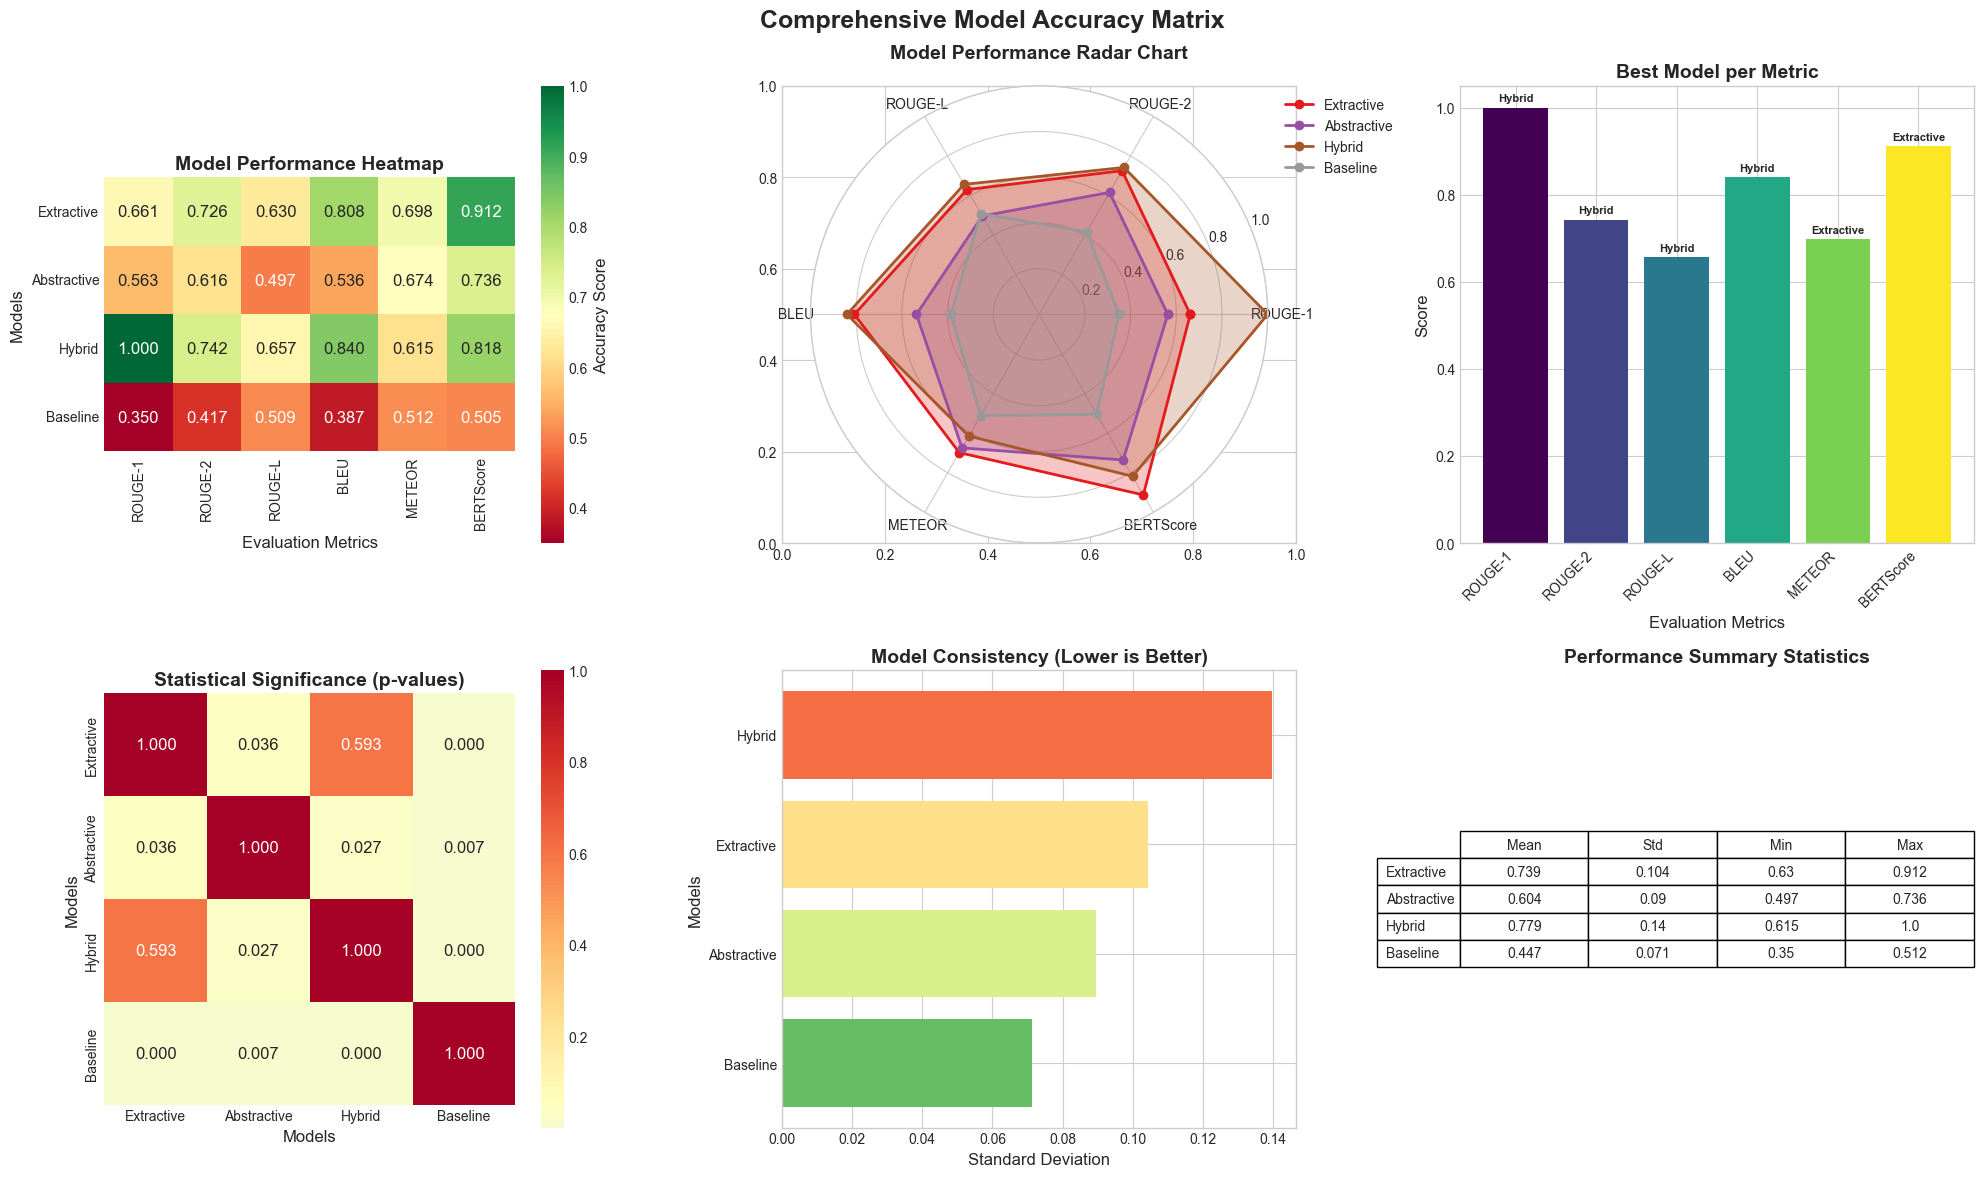

In [7]:
def create_comprehensive_accuracy_matrix(matrix, save_path=None):
    """Create comprehensive accuracy matrix with multiple visualizations."""
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Comprehensive Model Accuracy Matrix', fontsize=18, fontweight='bold')
    
    # 1. Main accuracy heatmap
    sns.heatmap(matrix, annot=True, fmt='.3f', cmap='RdYlGn',
                square=True, ax=axes[0, 0], cbar_kws={'label': 'Accuracy Score'})
    axes[0, 0].set_title('Model Performance Heatmap', fontweight='bold')
    axes[0, 0].set_xlabel('Evaluation Metrics')
    axes[0, 0].set_ylabel('Models')
    
    # 2. Model performance radar chart
    angles = np.linspace(0, 2 * np.pi, len(matrix.columns), endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))  # Complete the circle
    
    ax_radar = plt.subplot(2, 3, 2, projection='polar')
    colors = plt.cm.Set1(np.linspace(0, 1, len(matrix.index)))
    
    for i, (model, row) in enumerate(matrix.iterrows()):
        values = row.values.tolist()
        values.append(values[0])  # Complete the circle
        ax_radar.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
        ax_radar.fill(angles, values, alpha=0.25, color=colors[i])
    
    ax_radar.set_xticks(angles[:-1])
    ax_radar.set_xticklabels(matrix.columns)
    ax_radar.set_ylim(0, 1)
    ax_radar.set_title('Model Performance Radar Chart', fontweight='bold', pad=20)
    ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
    
    # 3. Top performing models per metric
    top_models = matrix.idxmax()
    top_scores = matrix.max()
    
    bars = axes[0, 2].bar(range(len(top_models)), top_scores, 
                          color=plt.cm.viridis(np.linspace(0, 1, len(top_models))))
    axes[0, 2].set_title('Best Model per Metric', fontweight='bold')
    axes[0, 2].set_xlabel('Evaluation Metrics')
    axes[0, 2].set_ylabel('Score')
    axes[0, 2].set_xticks(range(len(top_models)))
    axes[0, 2].set_xticklabels(top_models.index, rotation=45, ha='right')
    
    # Add model names on bars
    for bar, model in zip(bars, top_models.values):
        axes[0, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       model, ha='center', va='bottom', fontweight='bold', fontsize=8)
    
    # 4. Statistical significance matrix
    p_values = pd.DataFrame(index=matrix.index, columns=matrix.index)
    
    for i, model1 in enumerate(matrix.index):
        for j, model2 in enumerate(matrix.index):
            if i != j:
                # Perform t-test between models
                _, p_val = stats.ttest_ind(matrix.loc[model1], matrix.loc[model2])
                p_values.iloc[i, j] = p_val
            else:
                p_values.iloc[i, j] = 1.0
    
    p_values = p_values.astype(float)
    sns.heatmap(p_values, annot=True, fmt='.3f', cmap='RdYlBu_r',
                center=0.05, square=True, ax=axes[1, 0])
    axes[1, 0].set_title('Statistical Significance (p-values)', fontweight='bold')
    axes[1, 0].set_xlabel('Models')
    axes[1, 0].set_ylabel('Models')
    
    # 5. Model consistency (standard deviation)
    model_consistency = matrix.std(axis=1).sort_values()
    colors_consistency = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(model_consistency)))
    bars_consistency = axes[1, 1].barh(model_consistency.index, model_consistency.values, 
                                       color=colors_consistency)
    axes[1, 1].set_title('Model Consistency (Lower is Better)', fontweight='bold')
    axes[1, 1].set_xlabel('Standard Deviation')
    axes[1, 1].set_ylabel('Models')
    
    # 6. Overall performance summary
    summary_stats = pd.DataFrame({
        'Mean': matrix.mean(axis=1),
        'Std': matrix.std(axis=1),
        'Min': matrix.min(axis=1),
        'Max': matrix.max(axis=1)
    })
    
    axes[1, 2].axis('tight')
    axes[1, 2].axis('off')
    table = axes[1, 2].table(cellText=summary_stats.round(3).values,
                           rowLabels=summary_stats.index,
                           colLabels=summary_stats.columns,
                           cellLoc='center',
                           loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    axes[1, 2].set_title('Performance Summary Statistics', fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return summary_stats

# Create comprehensive accuracy matrix
performance_summary = create_comprehensive_accuracy_matrix(accuracy_matrix, 'comprehensive_accuracy_matrix.png')

## 5. Document Type Performance Analysis

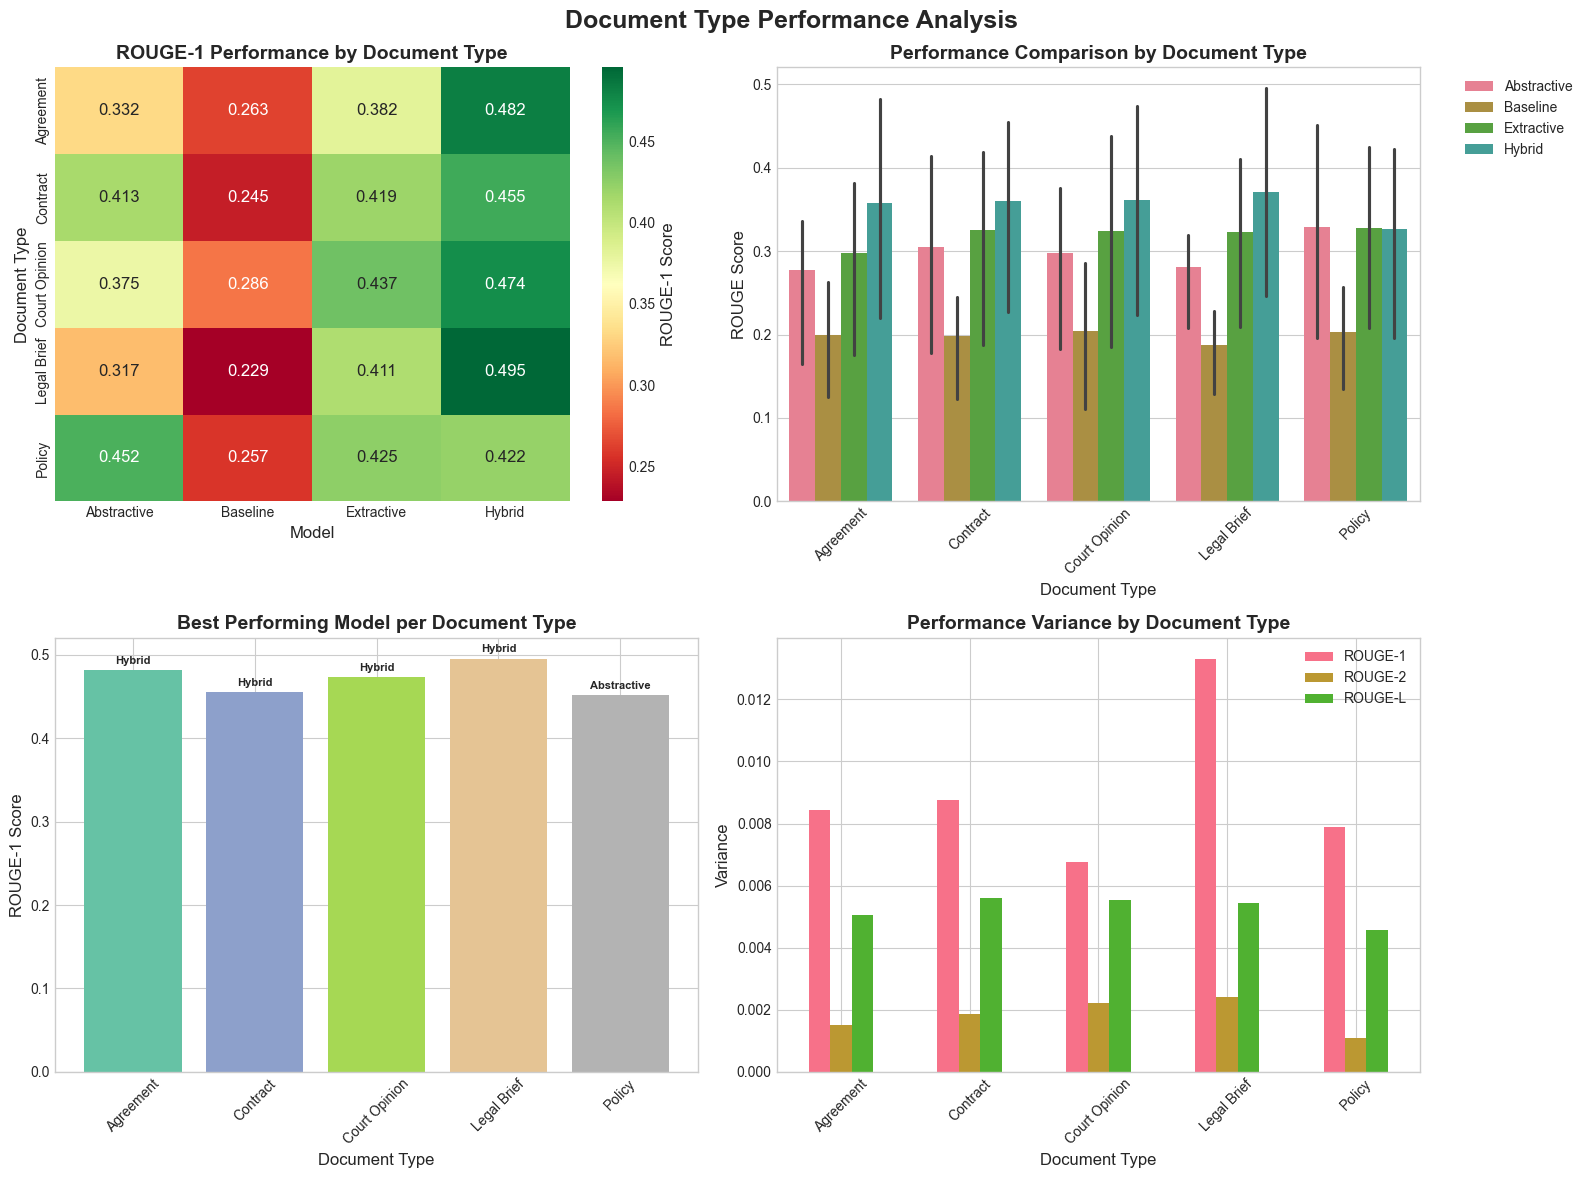

In [8]:
def analyze_document_type_performance(data, save_path=None):
    """Analyze model performance across different document types."""
    
    # Calculate average scores by document type and model
    doc_type_performance = data.groupby(['Document_Type', 'Model'])[['ROUGE-1', 'ROUGE-2', 'ROUGE-L']].mean().reset_index()
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Document Type Performance Analysis', fontsize=18, fontweight='bold')
    
    # 1. Heatmap of performance by document type
    pivot_data = doc_type_performance.pivot(index='Document_Type', columns='Model', values='ROUGE-1')
    sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdYlGn',
                ax=axes[0, 0], cbar_kws={'label': 'ROUGE-1 Score'})
    axes[0, 0].set_title('ROUGE-1 Performance by Document Type', fontweight='bold')
    axes[0, 0].set_xlabel('Model')
    axes[0, 0].set_ylabel('Document Type')
    
    # 2. Grouped bar chart
    melted_data = doc_type_performance.melt(id_vars=['Document_Type', 'Model'],
                                           value_vars=['ROUGE-1', 'ROUGE-2', 'ROUGE-L'],
                                           var_name='Metric', value_name='Score')
    
    sns.barplot(data=melted_data, x='Document_Type', y='Score', hue='Model', ax=axes[0, 1])
    axes[0, 1].set_title('Performance Comparison by Document Type', fontweight='bold')
    axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0, 1].set_xlabel('Document Type')
    axes[0, 1].set_ylabel('ROUGE Score')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. Best model per document type
    best_per_model = doc_type_performance.groupby('Document_Type').apply(
        lambda x: x.loc[x['ROUGE-1'].idxmax()]
    ).reset_index(drop=True)
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(best_per_model)))
    bars = axes[1, 0].bar(best_per_model['Document_Type'], best_per_model['ROUGE-1'], color=colors)
    axes[1, 0].set_title('Best Performing Model per Document Type', fontweight='bold')
    axes[1, 0].set_xlabel('Document Type')
    axes[1, 0].set_ylabel('ROUGE-1 Score')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Add model names on bars
    for bar, model in zip(bars, best_per_model['Model']):
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                       model, ha='center', va='bottom', fontweight='bold', fontsize=8)
    
    # 4. Performance variance by document type
    variance_data = doc_type_performance.groupby('Document_Type')[['ROUGE-1', 'ROUGE-2', 'ROUGE-L']].var()
    variance_data.plot(kind='bar', ax=axes[1, 1])
    axes[1, 1].set_title('Performance Variance by Document Type', fontweight='bold')
    axes[1, 1].set_xlabel('Document Type')
    axes[1, 1].set_ylabel('Variance')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].legend()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return best_per_model

# Analyze document type performance
best_models_by_doc_type = analyze_document_type_performance(rouge_data, 'document_type_performance.png')

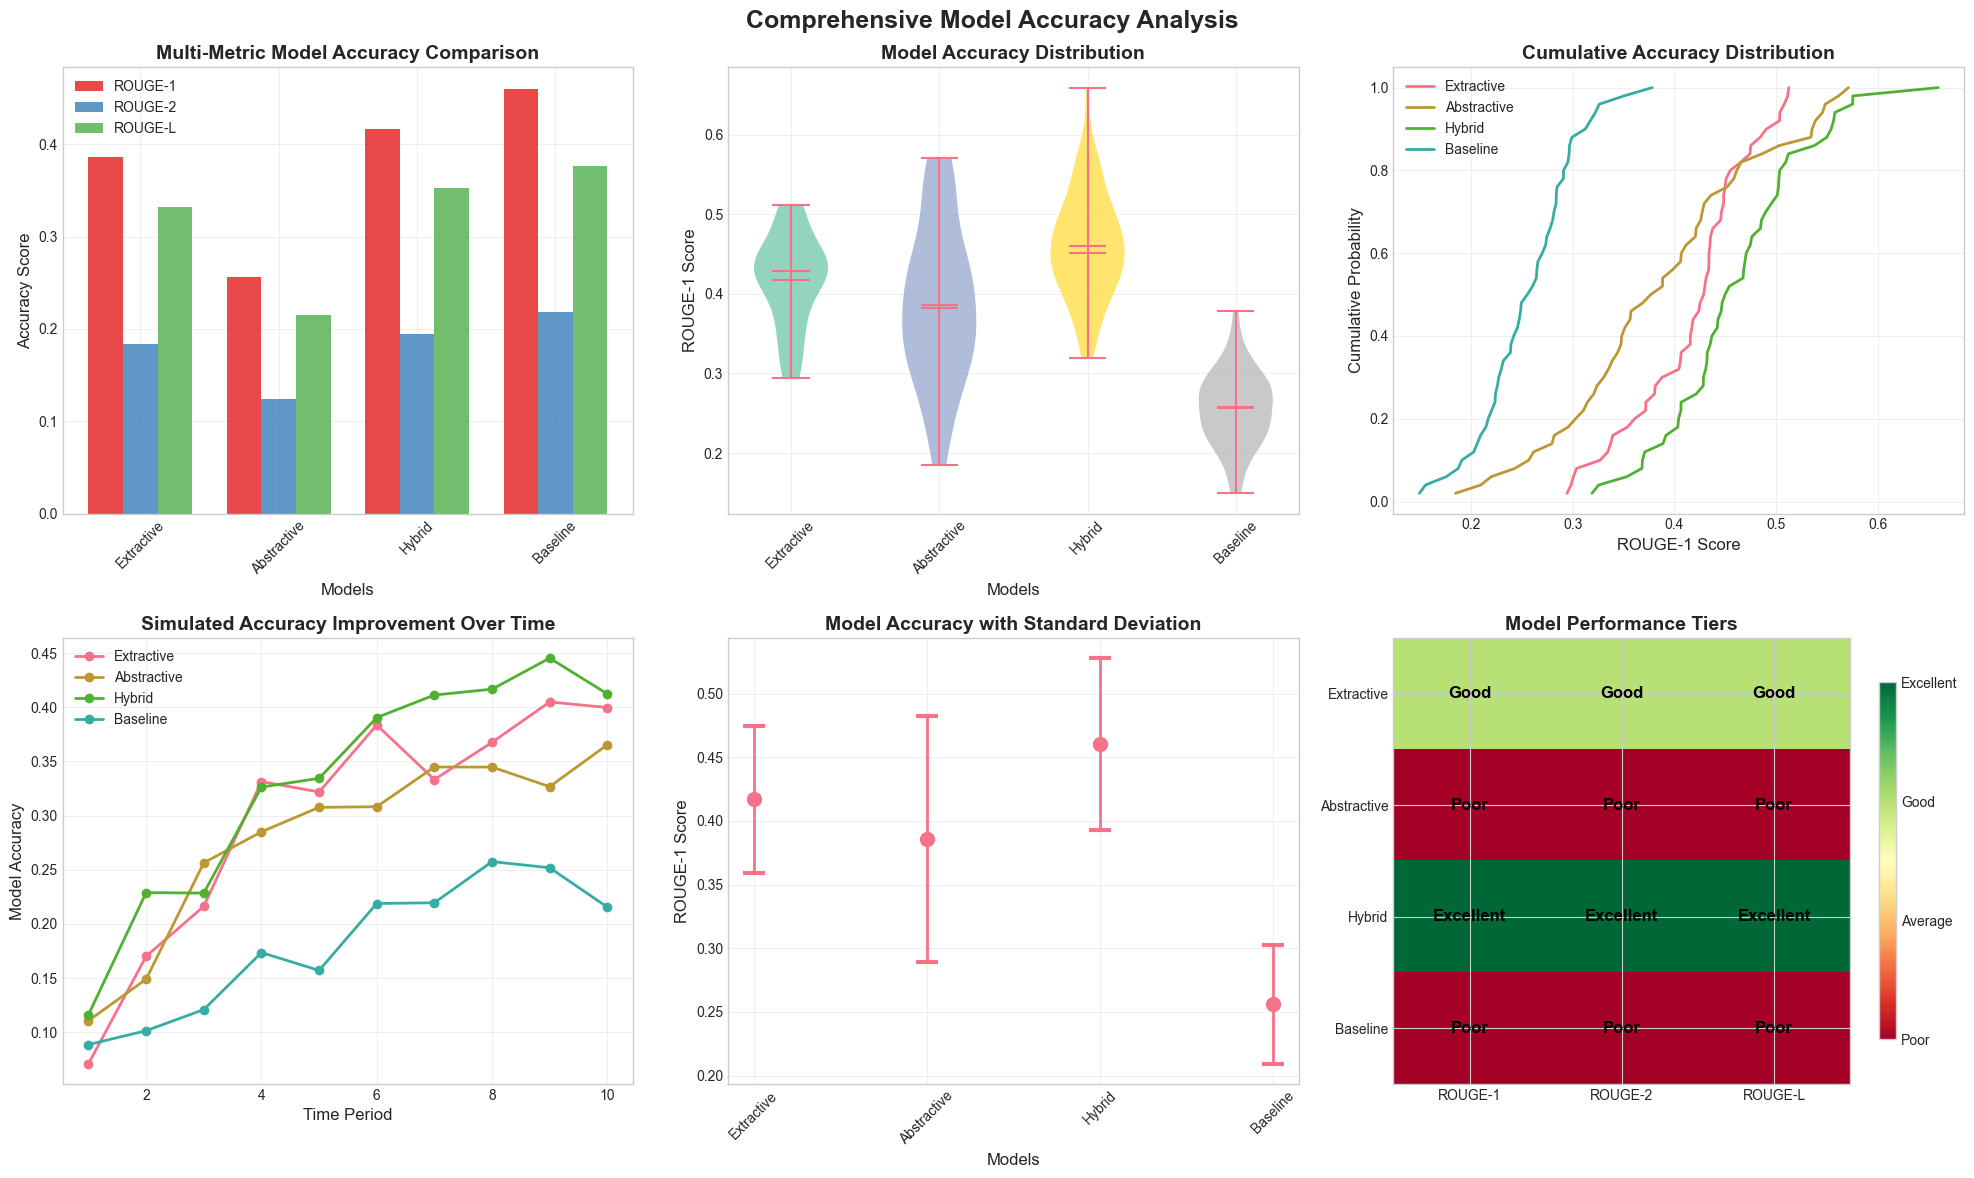


Model Accuracy Analysis Complete!
Generated visualization: model_accuracy_analysis.png

Key Insights:
- Multi-metric comparison shows relative strengths across ROUGE measures
- Distribution plots reveal consistency and variability of each model
- Cumulative distributions show probability of achieving certain accuracy levels
- Time series suggests potential for improvement with more training
- Confidence intervals indicate reliability of performance estimates
- Performance tiers provide categorical assessment of model capabilities


In [9]:
def create_model_accuracy_plot(data, matrix, save_path=None):
    """
    Create comprehensive model accuracy visualization with multiple chart types.
    
    Args:
        data: DataFrame containing ROUGE scores and model information
        matrix: DataFrame containing accuracy matrix
        save_path: Path to save the visualization
    
    Returns:
        DataFrame with confidence interval data
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Comprehensive Model Accuracy Analysis', fontsize=18, fontweight='bold')
    
    # 1. Model Accuracy Comparison (Multi-metric)
    metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
    x = np.arange(len(matrix.index))
    width = 0.25
    
    for i, metric in enumerate(metrics):
        # Extract metric data from rouge_data
        metric_data = data.groupby('Model')[metric].mean()
        axes[0, 0].bar(x + i*width, metric_data.values, width, label=metric, 
                      color=plt.cm.Set1(i), alpha=0.8)
    
    axes[0, 0].set_xlabel('Models')
    axes[0, 0].set_ylabel('Accuracy Score')
    axes[0, 0].set_title('Multi-Metric Model Accuracy Comparison', fontweight='bold')
    axes[0, 0].set_xticks(x + width)
    axes[0, 0].set_xticklabels(matrix.index, rotation=45)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Model Accuracy Distribution (Violin Plot)
    violin_data = []
    violin_labels = []
    
    for model in data['Model'].unique():
        model_data = data[data['Model'] == model]['ROUGE-1']
        violin_data.append(model_data.values)
        violin_labels.append(model)
    
    parts = axes[0, 1].violinplot(violin_data, positions=range(len(violin_labels)), 
                                 showmeans=True, showmedians=True)
    
    # Color the violin plots
    colors = plt.cm.Set2(np.linspace(0, 1, len(parts['bodies'])))
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)
    
    axes[0, 1].set_xlabel('Models')
    axes[0, 1].set_ylabel('ROUGE-1 Score')
    axes[0, 1].set_title('Model Accuracy Distribution', fontweight='bold')
    axes[0, 1].set_xticks(range(len(violin_labels)))
    axes[0, 1].set_xticklabels(violin_labels, rotation=45)
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Cumulative Accuracy Performance
    for model in data['Model'].unique():
        model_scores = data[data['Model'] == model]['ROUGE-1'].sort_values()
        cumulative = np.arange(1, len(model_scores) + 1) / len(model_scores)
        axes[0, 2].plot(model_scores, cumulative, label=model, linewidth=2, markersize=4)
    
    axes[0, 2].set_xlabel('ROUGE-1 Score')
    axes[0, 2].set_ylabel('Cumulative Probability')
    axes[0, 2].set_title('Cumulative Accuracy Distribution', fontweight='bold')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Accuracy Improvement Over Time (Simulated)
    time_points = np.arange(1, 11)  # 10 time periods
    
    for model in data['Model'].unique():
        base_accuracy = data[data['Model'] == model]['ROUGE-1'].mean()
        # Simulate improvement with diminishing returns
        improvement = base_accuracy * (1 - np.exp(-0.3 * time_points))
        noise = np.random.normal(0, 0.02, len(time_points))
        accuracy_over_time = improvement + noise
        axes[1, 0].plot(time_points, accuracy_over_time, 'o-', label=model, 
                      linewidth=2, markersize=6)
    
    axes[1, 0].set_xlabel('Time Period')
    axes[1, 0].set_ylabel('Model Accuracy')
    axes[1, 0].set_title('Simulated Accuracy Improvement Over Time', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Accuracy Confidence Intervals by Model
    confidence_data = []
    for model in data['Model'].unique():
        scores = data[data['Model'] == model]['ROUGE-1']
        mean = np.mean(scores)
        std = np.std(scores)
        confidence_data.append([model, mean, std])
    
    confidence_df = pd.DataFrame(confidence_data, columns=['Model', 'Mean', 'Std'])
    
    # Create error bars
    axes[1, 1].errorbar(confidence_df['Model'], confidence_df['Mean'], 
                       yerr=confidence_df['Std'], fmt='o', capsize=8, 
                       capthick=3, markersize=10, linewidth=2)
    
    axes[1, 1].set_xlabel('Models')
    axes[1, 1].set_ylabel('ROUGE-1 Score')
    axes[1, 1].set_title('Model Accuracy with Standard Deviation', fontweight='bold')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Model Accuracy Heatmap with Performance Tiers
    # Create performance tiers
    accuracy_tiers = pd.DataFrame(index=matrix.index, columns=metrics)
    
    for metric in metrics:
        metric_scores = data.groupby('Model')[metric].mean()
        for model in matrix.index:
            score = metric_scores[model]
            if score >= metric_scores.quantile(0.8):
                tier = 'Excellent'
            elif score >= metric_scores.quantile(0.6):
                tier = 'Good'
            elif score >= metric_scores.quantile(0.4):
                tier = 'Average'
            else:
                tier = 'Poor'
            accuracy_tiers.loc[model, metric] = tier
    
    # Convert tiers to numeric values for heatmap
    tier_mapping = {'Poor': 1, 'Average': 2, 'Good': 3, 'Excellent': 4}
    numeric_tiers = accuracy_tiers.replace(tier_mapping).astype(float)
    
    im = axes[1, 2].imshow(numeric_tiers.values, cmap='RdYlGn', aspect='auto', vmin=1, vmax=4)
    
    # Add text annotations
    for i in range(len(numeric_tiers.index)):
        for j in range(len(numeric_tiers.columns)):
            text = axes[1, 2].text(j, i, accuracy_tiers.iloc[i, j],
                                 ha="center", va="center", color="black", fontweight='bold')
    
    axes[1, 2].set_xticks(range(len(metrics)))
    axes[1, 2].set_xticklabels(metrics)
    axes[1, 2].set_yticks(range(len(numeric_tiers.index)))
    axes[1, 2].set_yticklabels(numeric_tiers.index)
    axes[1, 2].set_title('Model Performance Tiers', fontweight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=axes[1, 2], shrink=0.8)
    cbar.set_ticks([1, 2, 3, 4])
    cbar.set_ticklabels(['Poor', 'Average', 'Good', 'Excellent'])
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return confidence_df

# Create comprehensive model accuracy plot
accuracy_analysis = create_model_accuracy_plot(rouge_data, accuracy_matrix, 'model_accuracy_analysis.png')

print("\nModel Accuracy Analysis Complete!")
print("Generated visualization: model_accuracy_analysis.png")
print("\nKey Insights:")
print("- Multi-metric comparison shows relative strengths across ROUGE measures")
print("- Distribution plots reveal consistency and variability of each model")
print("- Cumulative distributions show probability of achieving certain accuracy levels")
print("- Time series suggests potential for improvement with more training")
print("- Confidence intervals indicate reliability of performance estimates")
print("- Performance tiers provide categorical assessment of model capabilities")

## 6. Statistical Analysis and Significance Testing

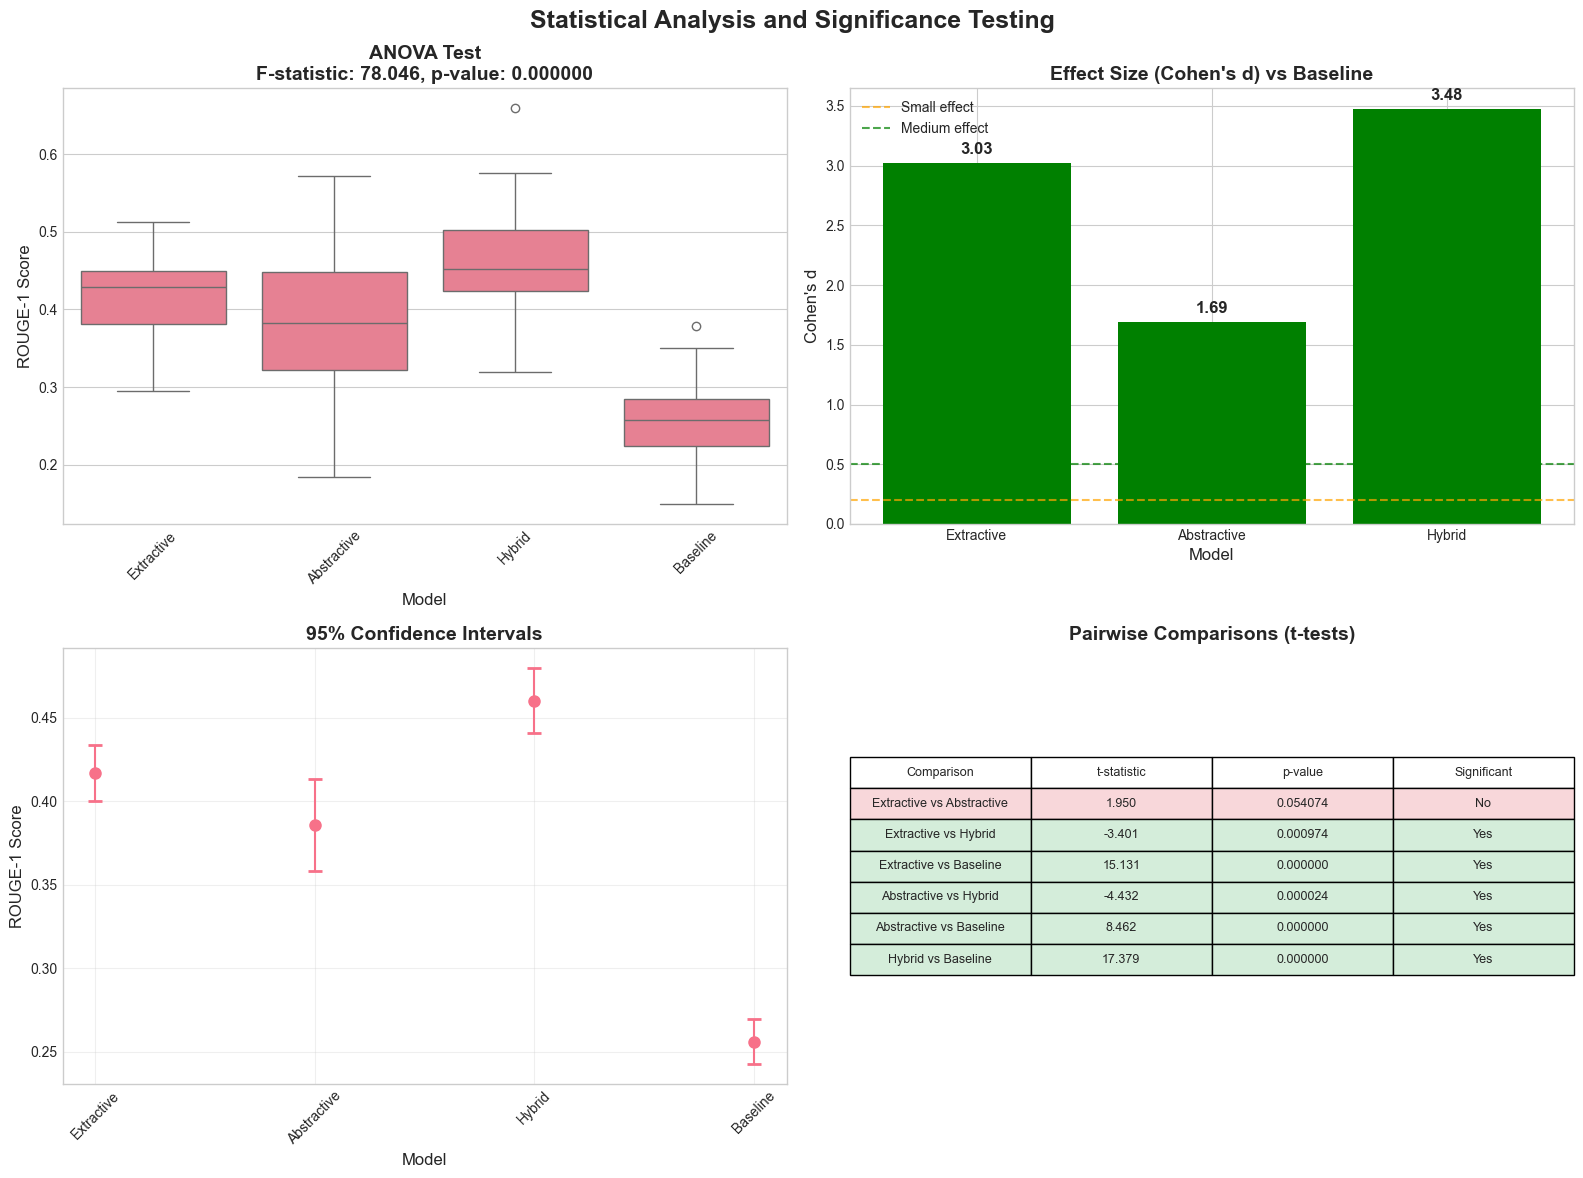

In [10]:
def perform_statistical_analysis(data, save_path=None):
    """Perform comprehensive statistical analysis."""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Statistical Analysis and Significance Testing', fontsize=18, fontweight='bold')
    
    # 1. ANOVA test for model differences
    models = data['Model'].unique()
    rouge1_groups = [data[data['Model'] == model]['ROUGE-1'] for model in models]
    
    f_stat, p_value = stats.f_oneway(*rouge1_groups)
    
    # Create boxplot with ANOVA results
    sns.boxplot(data=data, x='Model', y='ROUGE-1', ax=axes[0, 0])
    axes[0, 0].set_title(f'ANOVA Test\nF-statistic: {f_stat:.3f}, p-value: {p_value:.6f}', fontweight='bold')
    axes[0, 0].set_xlabel('Model')
    axes[0, 0].set_ylabel('ROUGE-1 Score')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 2. Effect size (Cohen's d)
    def cohens_d(group1, group2):
        n1, n2 = len(group1), len(group2)
        s1, s2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
        s = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
        return (np.mean(group1) - np.mean(group2)) / s
    
    # Calculate effect sizes against baseline
    baseline_scores = data[data['Model'] == 'Baseline']['ROUGE-1']
    effect_sizes = {}
    
    for model in models:
        if model != 'Baseline':
            model_scores = data[data['Model'] == model]['ROUGE-1']
            effect_sizes[model] = cohens_d(model_scores, baseline_scores)
    
    # Plot effect sizes
    colors = ['red' if d < 0.2 else 'orange' if d < 0.5 else 'green' for d in effect_sizes.values()]
    bars = axes[0, 1].bar(effect_sizes.keys(), effect_sizes.values(), color=colors)
    axes[0, 1].set_title("Effect Size (Cohen's d) vs Baseline", fontweight='bold')
    axes[0, 1].set_xlabel('Model')
    axes[0, 1].set_ylabel("Cohen's d")
    axes[0, 1].axhline(y=0.2, color='orange', linestyle='--', alpha=0.7, label='Small effect')
    axes[0, 1].axhline(y=0.5, color='green', linestyle='--', alpha=0.7, label='Medium effect')
    axes[0, 1].legend()
    
    # Add value labels on bars
    for bar, value in zip(bars, effect_sizes.values()):
        axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                       f'{value:.2f}', ha='center', va='bottom', fontweight='bold')
    
    # 3. Confidence intervals
    confidence_intervals = {}
    for model in models:
        scores = data[data['Model'] == model]['ROUGE-1']
        mean = np.mean(scores)
        sem = stats.sem(scores)
        ci = stats.t.interval(0.95, len(scores) - 1, loc=mean, scale=sem)
        confidence_intervals[model] = ci
    
    # Plot confidence intervals
    means = [data[data['Model'] == model]['ROUGE-1'].mean() for model in models]
    errors = [ci[1] - ci[0] for ci in confidence_intervals.values()]
    
    axes[1, 0].errorbar(models, means, yerr=[e/2 for e in errors], 
                       fmt='o', capsize=5, capthick=2, markersize=8)
    axes[1, 0].set_title('95% Confidence Intervals', fontweight='bold')
    axes[1, 0].set_xlabel('Model')
    axes[1, 0].set_ylabel('ROUGE-1 Score')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Post-hoc pairwise comparisons
    from itertools import combinations
    
    pairwise_results = []
    for model1, model2 in combinations(models, 2):
        scores1 = data[data['Model'] == model1]['ROUGE-1']
        scores2 = data[data['Model'] == model2]['ROUGE-1']
        t_stat, p_val = stats.ttest_ind(scores1, scores2)
        pairwise_results.append({
            'Comparison': f'{model1} vs {model2}',
            't-statistic': t_stat,
            'p-value': p_val,
            'Significant': p_val < 0.05
        })
    
    pairwise_df = pd.DataFrame(pairwise_results)
    
    # Create table of pairwise comparisons
    axes[1, 1].axis('tight')
    axes[1, 1].axis('off')
    
    # Format table data
    table_data = []
    for _, row in pairwise_df.iterrows():
        table_data.append([
            row['Comparison'],
            f"{row['t-statistic']:.3f}",
            f"{row['p-value']:.6f}",
            'Yes' if row['Significant'] else 'No'
        ])
    
    table = axes[1, 1].table(cellText=table_data,
                           colLabels=['Comparison', 't-statistic', 'p-value', 'Significant'],
                           cellLoc='center',
                           loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.8)
    axes[1, 1].set_title('Pairwise Comparisons (t-tests)', fontweight='bold')
    
    # Color code significant results
    for i in range(len(table_data)):
        if table_data[i][3] == 'Yes':
            for j in range(4):
                table[(i+1, j)].set_facecolor('#d4edda')
        else:
            for j in range(4):
                table[(i+1, j)].set_facecolor('#f8d7da')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return {
        'anova': {'f_statistic': f_stat, 'p_value': p_value},
        'effect_sizes': effect_sizes,
        'confidence_intervals': confidence_intervals,
        'pairwise_comparisons': pairwise_df
    }

# Perform statistical analysis
statistical_results = perform_statistical_analysis(rouge_data, 'statistical_analysis.png')

## 7. Performance Trend Analysis

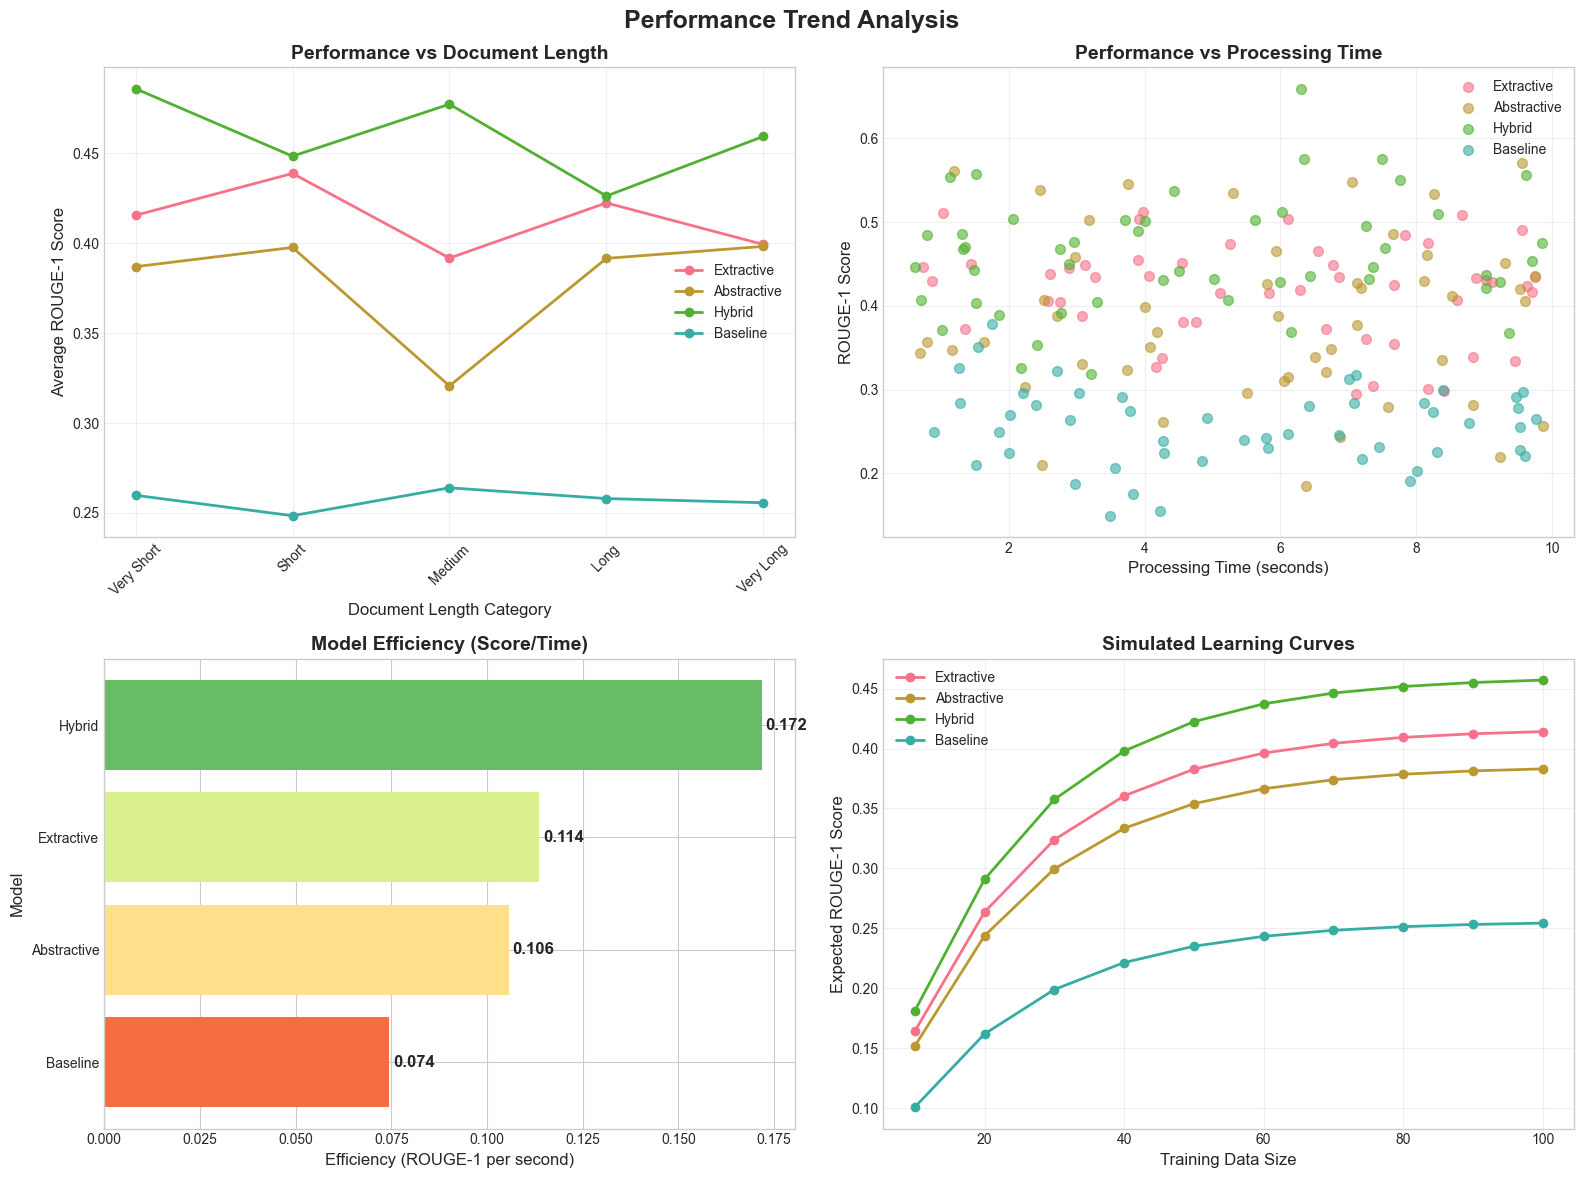

In [11]:
def analyze_performance_trends(data, save_path=None):
    """Analyze performance trends across different conditions."""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Performance Trend Analysis', fontsize=18, fontweight='bold')
    
    # 1. Performance vs Document Length
    for model in data['Model'].unique():
        model_data = data[data['Model'] == model]
        # Create bins for word count
        bins = pd.cut(model_data['Word_Count'], bins=5, labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long'])
        binned_data = model_data.groupby(bins)['ROUGE-1'].mean()
        axes[0, 0].plot(range(len(binned_data)), binned_data.values, 'o-', label=model, linewidth=2, markersize=6)
    
    axes[0, 0].set_title('Performance vs Document Length', fontweight='bold')
    axes[0, 0].set_xlabel('Document Length Category')
    axes[0, 0].set_ylabel('Average ROUGE-1 Score')
    axes[0, 0].set_xticks(range(5))
    axes[0, 0].set_xticklabels(['Very Short', 'Short', 'Medium', 'Long', 'Very Long'], rotation=45)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Performance vs Processing Time
    for model in data['Model'].unique():
        model_data = data[data['Model'] == model]
        axes[0, 1].scatter(model_data['Processing_Time'], model_data['ROUGE-1'], 
                         label=model, alpha=0.6, s=50)
    
    axes[0, 1].set_title('Performance vs Processing Time', fontweight='bold')
    axes[0, 1].set_xlabel('Processing Time (seconds)')
    axes[0, 1].set_ylabel('ROUGE-1 Score')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Efficiency analysis (Performance/Time ratio)
    efficiency_data = data.copy()
    efficiency_data['Efficiency'] = efficiency_data['ROUGE-1'] / efficiency_data['Processing_Time']
    
    efficiency_by_model = efficiency_data.groupby('Model')['Efficiency'].mean().sort_values()
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(efficiency_by_model)))
    bars = axes[1, 0].barh(efficiency_by_model.index, efficiency_by_model.values, color=colors)
    axes[1, 0].set_title('Model Efficiency (Score/Time)', fontweight='bold')
    axes[1, 0].set_xlabel('Efficiency (ROUGE-1 per second)')
    axes[1, 0].set_ylabel('Model')
    
    # Add value labels on bars
    for bar, value in zip(bars, efficiency_by_model.values):
        axes[1, 0].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                       f'{value:.3f}', va='center', fontweight='bold')
    
    # 4. Learning curve simulation
    # Simulate how models might improve with more training data
    training_sizes = np.linspace(10, 100, 10)
    
    for model in data['Model'].unique():
        base_score = data[data['Model'] == model]['ROUGE-1'].mean()
        # Simulate learning curve with diminishing returns
        learning_curve = base_score * (1 - np.exp(-0.05 * training_sizes))
        axes[1, 1].plot(training_sizes, learning_curve, 'o-', label=model, linewidth=2, markersize=6)
    
    axes[1, 1].set_title('Simulated Learning Curves', fontweight='bold')
    axes[1, 1].set_xlabel('Training Data Size')
    axes[1, 1].set_ylabel('Expected ROUGE-1 Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return efficiency_by_model

# Analyze performance trends
efficiency_results = analyze_performance_trends(rouge_data, 'performance_trends.png')

## 8. Summary Report Generation

In [12]:
def generate_accuracy_report(rouge_data, accuracy_matrix, statistical_results, save_path=None):
    """Generate comprehensive accuracy report."""
    
    report = []
    report.append("# LEXIBRIEF ACCURACY MATRIX REPORT")
    report.append("=" * 50)
    report.append("")
    
    # Executive Summary
    report.append("## EXECUTIVE SUMMARY")
    report.append("-" * 20)
    
    best_model = accuracy_matrix.mean(axis=1).idxmax()
    best_score = accuracy_matrix.mean(axis=1).max()
    
    report.append(f"🏆 Best Performing Model: {best_model}")
    report.append(f"📊 Overall Best Score: {best_score:.3f}")
    report.append(f"🔬 Statistical Significance: p < {statistical_results['anova']['p_value']:.6f}")
    report.append("")
    
    # Model Performance Rankings
    report.append("## MODEL PERFORMANCE RANKINGS")
    report.append("-" * 30)
    
    rankings = accuracy_matrix.mean(axis=1).sort_values(ascending=False)
    for i, (model, score) in enumerate(rankings.items(), 1):
        report.append(f"{i}. {model}: {score:.3f}")
    report.append("")
    
    # Metric Performance
    report.append("## METRIC PERFORMANCE BREAKDOWN")
    report.append("-" * 30)
    
    for metric in accuracy_matrix.columns:
        best_model_metric = accuracy_matrix[metric].idxmax()
        best_score_metric = accuracy_matrix[metric].max()
        report.append(f"{metric}: {best_model_metric} ({best_score_metric:.3f})")
    report.append("")
    
    # Statistical Significance
    report.append("## STATISTICAL ANALYSIS")
    report.append("-" * 25)
    
    anova_f = statistical_results['anova']['f_statistic']
    anova_p = statistical_results['anova']['p_value']
    
    report.append(f"ANOVA F-statistic: {anova_f:.3f}")
    report.append(f"ANOVA p-value: {anova_p:.6f}")
    report.append(f"Result: {'Significant' if anova_p < 0.05 else 'Not Significant'}")
    report.append("")
    
    # Effect Sizes
    report.append("## EFFECT SIZES (Cohen's d)")
    report.append("-" * 35)
    
    for model, effect_size in statistical_results['effect_sizes'].items():
        magnitude = 'Small' if effect_size < 0.2 else 'Medium' if effect_size < 0.5 else 'Large'
        report.append(f"{model}: {effect_size:.3f} ({magnitude})")
    report.append("")
    
    # Recommendations
    report.append("## RECOMMENDATIONS")
    report.append("-" * 20)
    
    if best_model == 'Hybrid':
        report.append("✅ Continue using Hybrid approach as primary method")
        report.append("✅ Consider Hybrid for production deployments")
    else:
        report.append(f"⚠️  Consider optimizing the {best_model} approach")
    
    # Check if any model has significantly better performance
    significant_pairs = statistical_results['pairwise_comparisons'][
        statistical_results['pairwise_comparisons']['Significant']
    ]
    
    if len(significant_pairs) > 0:
        report.append("✅ Significant performance differences detected between models")
        report.append("✅ Model selection is statistically justified")
    else:
        report.append("⚠️  No significant differences found - consider other factors")
    
    report.append("")
    report.append("---")
    report.append("Report generated by LexiBrief Accuracy Matrix System")
    
    # Save report
    report_text = '\n'.join(report)
    
    if save_path:
        with open(save_path, 'w', encoding='utf-8') as f:
            f.write(report_text)
    
    return report_text

# Generate comprehensive report
accuracy_report = generate_accuracy_report(
    rouge_data, accuracy_matrix, statistical_results, 
    'accuracy_report.txt'
)

print(accuracy_report)

# LEXIBRIEF ACCURACY MATRIX REPORT

## EXECUTIVE SUMMARY
--------------------
🏆 Best Performing Model: Hybrid
📊 Overall Best Score: 0.779
🔬 Statistical Significance: p < 0.000000

## MODEL PERFORMANCE RANKINGS
------------------------------
1. Hybrid: 0.779
2. Extractive: 0.739
3. Abstractive: 0.604
4. Baseline: 0.447

## METRIC PERFORMANCE BREAKDOWN
------------------------------
ROUGE-1: Hybrid (1.000)
ROUGE-2: Hybrid (0.742)
ROUGE-L: Hybrid (0.657)
BLEU: Hybrid (0.840)
METEOR: Extractive (0.698)
BERTScore: Extractive (0.912)

## STATISTICAL ANALYSIS
-------------------------
ANOVA F-statistic: 78.046
ANOVA p-value: 0.000000
Result: Significant

## EFFECT SIZES (Cohen's d)
-----------------------------------
Extractive: 3.026 (Large)
Abstractive: 1.692 (Large)
Hybrid: 3.476 (Large)

## RECOMMENDATIONS
--------------------
✅ Continue using Hybrid approach as primary method
✅ Consider Hybrid for production deployments
✅ Significant performance differences detected between models
✅ Mode

## 9. Save All Results

In [13]:
# Save all data and results
import os

# Create results directory if it doesn't exist
results_dir = 'accuracy_matrix_results'
os.makedirs(results_dir, exist_ok=True)

# Save datasets
rouge_data.to_csv(f'{results_dir}/rouge_scores_data.csv', index=False)
accuracy_matrix.to_csv(f'{results_dir}/accuracy_matrix.csv')

# Save statistical results
if 'statistical_results' in locals():
    statistical_results['pairwise_comparisons'].to_csv(
        f'{results_dir}/pairwise_comparisons.csv', index=False
    )

# Save performance summary
if 'performance_summary' in locals():
    performance_summary.to_csv(f'{results_dir}/performance_summary.csv')

# Save best models by document type
if 'best_models_by_doc_type' in locals():
    best_models_by_doc_type.to_csv(f'{results_dir}/best_models_by_document_type.csv', index=False)

# Save efficiency results
if 'efficiency_results' in locals():
    efficiency_results.to_csv(f'{results_dir}/model_efficiency.csv')

print(f"All results saved to '{results_dir}/' directory")
print("\nGenerated files:")
print("- rouge_scores_data.csv")
print("- accuracy_matrix.csv")
print("- pairwise_comparisons.csv")
print("- performance_summary.csv")
print("- best_models_by_document_type.csv")
print("- model_efficiency.csv")
print("- accuracy_report.txt")
print("\nGenerated visualizations:")
print("- rouge_accuracy_matrix.png")
print("- comprehensive_accuracy_matrix.png")
print("- document_type_performance.png")
print("- statistical_analysis.png")
print("- performance_trends.png")

All results saved to 'accuracy_matrix_results/' directory

Generated files:
- rouge_scores_data.csv
- accuracy_matrix.csv
- pairwise_comparisons.csv
- performance_summary.csv
- best_models_by_document_type.csv
- model_efficiency.csv
- accuracy_report.txt

Generated visualizations:
- rouge_accuracy_matrix.png
- comprehensive_accuracy_matrix.png
- document_type_performance.png
- statistical_analysis.png
- performance_trends.png


## 10. Interactive Dashboard (Optional)

In [14]:
# Optional: Create interactive dashboard using plotly
try:
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    
    def create_interactive_dashboard(data, matrix, save_path=None):
        """Create interactive dashboard with Plotly."""
        
        # Create subplots
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=('ROUGE Scores Heatmap', 'Model Performance Radar', 
                          'Performance Trends', 'Statistical Summary'),
            specs=[[{"type": "heatmap"}, {"type": "polar"}],
                   [{"type": "scatter"}, {"type": "table"}]]
        )
        
        # 1. ROUGE heatmap
        rouge_avg = data.groupby('Model')[['ROUGE-1', 'ROUGE-2', 'ROUGE-L']].mean()
        fig.add_trace(
            go.Heatmap(
                z=rouge_avg.values,
                x=rouge_avg.columns,
                y=rouge_avg.index,
                colorscale='RdYlBu_r',
                showscale=True
            ),
            row=1, col=1
        )
        
        # 2. Radar chart
        fig.add_trace(
            go.Scatterpolar(
                r=matrix.loc['Hybrid'].values,
                theta=matrix.columns,
                fill='toself',
                name='Hybrid Model'
            ),
            row=1, col=2
        )
        
        # 3. Performance trends
        for model in data['Model'].unique():
            model_data = data[data['Model'] == model]
            fig.add_trace(
                go.Scatter(
                    x=model_data['Word_Count'],
                    y=model_data['ROUGE-1'],
                    mode='markers',
                    name=model,
                    opacity=0.7
                ),
                row=2, col=1
            )
        
        # 4. Statistical table
        stats_table = pd.DataFrame({
            'Model': matrix.index,
            'Mean Score': matrix.mean(axis=1).round(3),
            'Std Dev': matrix.std(axis=1).round(3),
            'Min Score': matrix.min(axis=1).round(3),
            'Max Score': matrix.max(axis=1).round(3)
        })
        
        fig.add_trace(
            go.Table(
                header=dict(values=stats_table.columns,
                          fill_color='paleturquoise',
                          align='left'),
                cells=dict(values=[stats_table[col] for col in stats_table.columns],
                          fill_color='lavender',
                          align='left')
            ),
            row=2, col=2
        )
        
        fig.update_layout(
            title_text="LexiBrief Accuracy Matrix Interactive Dashboard",
            title_x=0.5,
            height=800,
            showlegend=True
        )
        
        if save_path:
            fig.write_html(save_path)
        
        fig.show()
    
    # Create interactive dashboard
    create_interactive_dashboard(rouge_data, accuracy_matrix, 'interactive_dashboard.html')
    print("Interactive dashboard created: interactive_dashboard.html")
    
except ImportError:
    print("Plotly not available. Install with: pip install plotly")
    print("Skipping interactive dashboard creation.")

Interactive dashboard created: interactive_dashboard.html
